# EDA

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math




sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

pd.set_option('display.max_columns', None)
pd.options.display.max_info_columns = 200

pd.set_option('display.float_format', '{:.3f}'.format)

In [124]:
df = pd.read_parquet('../data/interim/cleaned_loans.parquet')

In [29]:
dictionary = pd.read_csv("../data/raw/Lending_Club_Diccionario_Profesional.csv")
dictionary = dict(zip(dictionary['Variable'].str.strip(), dictionary['Descripcion_ES']))

In [104]:
eliminar_vars = []

In [11]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,mths_since_rcnt_il,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method
0,3600.000,3600.000,3600.000,36 months,13.990,123.030,C,C4,10+ years,MORTGAGE,55000.000,Not Verified,2015-12-01,0,n,debt_consolidation,PA,5.910,0.000,2003-08-01,675.000,679.000,1.000,30.000,NaN,7.000,0.000,2765.000,29.700,13.000,w,2019-03-01,564.000,560.000,0.000,30.000,Individual,0.000,722.000,144904.000,21.000,9300.000,4.000,20701.000,1506.000,37.200,0.000,0.000,148.000,128.000,3.000,3.000,1.000,4.000,69.000,4.000,69.000,2.000,2.000,4.000,2.000,5.000,3.000,4.000,9.000,4.000,7.000,0.000,0.000,0.000,3.000,76.900,0.000,0.000,0.000,178050.000,7746.000,2400.000,13734.000,Cash
1,24700.000,24700.000,24700.000,36 months,11.990,820.280,C,C1,10+ years,MORTGAGE,65000.000,Not Verified,2015-12-01,0,n,small_business,SD,16.060,1.000,1999-12-01,715.000,719.000,4.000,6.000,NaN,22.000,0.000,21470.000,19.200,38.000,w,2019-03-01,699.000,695.000,0.000,NaN,Individual,0.000,0.000,204396.000,19.000,111800.000,4.000,9733.000,57830.000,27.100,0.000,0.000,113.000,192.000,2.000,2.000,4.000,2.000,NaN,0.000,6.000,0.000,5.000,5.000,13.000,17.000,6.000,20.000,27.000,5.000,22.000,0.000,0.000,0.000,2.000,97.400,7.700,0.000,0.000,314017.000,39475.000,79300.000,24667.000,Cash
2,20000.000,20000.000,20000.000,60 months,10.780,432.660,B,B4,10+ years,MORTGAGE,63000.000,Not Verified,2015-12-01,0,n,home_improvement,IL,10.780,0.000,2000-08-01,695.000,699.000,0.000,NaN,NaN,6.000,0.000,7869.000,56.200,18.000,w,2019-03-01,704.000,700.000,0.000,NaN,Joint App,0.000,0.000,189699.000,19.000,14000.000,6.000,31617.000,2737.000,55.900,0.000,0.000,125.000,184.000,14.000,14.000,5.000,101.000,NaN,10.000,NaN,0.000,2.000,3.000,2.000,4.000,6.000,4.000,7.000,3.000,6.000,0.000,0.000,0.000,0.000,100.000,50.000,0.000,0.000,218418.000,18696.000,6200.000,14877.000,Cash
3,10400.000,10400.000,10400.000,60 months,22.450,289.910,F,F1,3 years,MORTGAGE,104433.000,Source Verified,2015-12-01,0,n,major_purchase,PA,25.370,1.000,1998-06-01,695.000,699.000,3.000,12.000,NaN,12.000,0.000,21929.000,64.500,35.000,w,2018-03-01,704.000,700.000,0.000,NaN,Individual,0.000,0.000,331730.000,14.000,34000.000,10.000,27644.000,4567.000,77.500,0.000,0.000,128.000,210.000,4.000,4.000,6.000,4.000,12.000,1.000,12.000,0.000,4.000,6.000,5.000,9.000,10.000,7.000,19.000,6.000,12.000,0.000,0.000,0.000,4.000,96.600,60.000,0.000,0.000,439570.000,95768.000,20300.000,88097.000,Cash
4,11950.000,11950.000,11950.000,36 months,13.440,405.180,C,C3,4 years,RENT,34000.000,Source Verified,2015-12-01,0,n,debt_consolidation,GA,10.200,0.000,1987-10-01,690.000,694.000,0.000,NaN,NaN,5.000,0.000,8822.000,68.400,6.000,w,2017-05-01,759.000,755.000,0.000,NaN,Individual,0.000,0.000,12798.000,338.000,12900.000,0.000,2560.000,844.000,91.000,0.000,0.000,338.000,54.000,32.000,32.000,0.000,36.000,NaN,NaN,NaN,0.000,2.000,3.000,2.000,2.00

In [12]:
df.shape

(1369566, 80)

## 1. Análisis de la Variable Objetivo

In [13]:
TARGET = 'loan_status'  # 0 = paid off, 1 = defaulted

Análisis de la Variable Objetivo (target):
loan_status
0   0.788
1   0.212
Name: proportion, dtype: float64


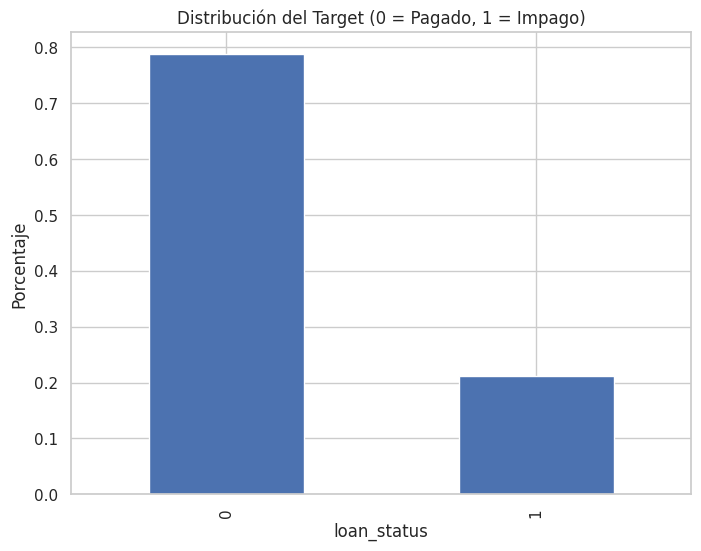

In [41]:
print("Análisis de la Variable Objetivo (target):")
print(df[TARGET].value_counts(normalize=True))

# Visualización
df[TARGET].value_counts(normalize=True).plot(
    kind='bar',
    title='Distribución del Target (0 = Pagado, 1 = Impago)'
)
plt.ylabel('Porcentaje')
plt.show()

Conclusión: Se necesitará probar técnicas de Oversampling o Unidersampling por tener el TARGET desbalanceado. Esto confirma que accuracy será una métrica inútil y deberemos optimizar para Recall.

In [15]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

date_cols = df.select_dtypes(include=['datetime']).columns.tolist()

print(f"Columnas Categóricas: {categorical_cols}")
print(f"Columnas Numéricas: {numerical_cols}")
print(f"Columnas de Fecha: {date_cols}")

Columnas Categóricas: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'disbursement_method']
Columnas Numéricas: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'mths_since_rcnt_il', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq'

In [56]:
print("Cantidad de Columnas Categóricas:", len(categorical_cols))
print("Cantidad de Columnas Numéricas:", len(numerical_cols))
print("Cantidad de Columnas de Fecha:", len(date_cols))

Cantidad de Columnas Categóricas: 12
Cantidad de Columnas Numéricas: 64
Cantidad de Columnas de Fecha: 3


## ANALIZAR LAS VARIABLES DE TIPO DATETIME

Analizamos los significados de las fechas que tenemos

In [105]:
for var_fecha in date_cols:
    print(f"Análisis de la variable: {var_fecha}")
    print("significa: ", dictionary[var_fecha])

Análisis de la variable: issue_d
significa:  La fecha (mes/año) en que el préstamo fue financiado y entregado.
Análisis de la variable: earliest_cr_line
significa:  Fecha (mes/año) en que se abrió la primera línea de crédito del cliente.
Análisis de la variable: last_credit_pull_d
significa:  La fecha más reciente en que LendingClub revisó el historial crediticio de este cliente.


variables a eliminar de fecha:

- issue_d (Fecha de Emisión del Préstamo) Es una consecuencia de que el préstamo fue aprobado, no una causa. Debes eliminarla.
- last_credit_pull_d: Esta es una columna que se actualiza después del momento de la predicción. Debes eliminarla.

In [106]:
eliminar_vars.append("issue_d") 
eliminar_vars.append("last_credit_pull_d")

Resumen de datos numericos

In [16]:
df[numerical_cols].describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,mths_since_rcnt_il,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,1369566.000,1369566.000,1369566.000,1369566.000,1369566.000,1369139.000,1368949.000,1369537.000,1369566.000,1369566.000,1369536.000,679440.000,233452.000,1369537.000,1369537.000,1369566.000,1368622.000,1369537.000,1369353.000,1332816.000,1369421.000,360306.000,1369536.000,1299290.000,1299290.000,542554.000,1299290.000,1319536.000,1299267.000,1305362.000,1304505.000,1369421.000,1369537.000,1260457.000,1299289.000,1299289.000,1299290.000,1319536.000,1306300.000,324455.000,1190992.000,457588.000,1299290.000,1299290.000,1299290.000,1310976.000,1299290.000,1299290.000,1299290.000,1299289.000,1299290.000,1310976.000,1248056.000,1299290.000,1299290.000,1299290.000,1299136.000,1304949.000,1368201.000,1369461.000,1299290.000,1319536.000,1319536.000,1299290.000
mean,14448.774,14440.100,14412.806,13.279,438.759,76273.643,18.230,0.318,696.102,700.102,0.662,34.282,70.489,11.591,0.215,16250.940,51.774,24.947,676.190,677.047,0.017,43.701,0.005,249.117,140928.402,19.609,32763.182,4.699,13465.563,10182.314,59.884,0.009,14.897,125.729,181.291,13.107,7.849,1.664,23.783,39.625,6.707,35.792,0.511,3.644,5.646,4.736,8.087,8.564,8.279,14.590,5.594,11.639,0.001,0.003,0.089,2.182,94.148,45.095,0.135,0.052,174157.829,49695.339,21616.565,42183.797
std,8737.507,8733.728,8739.796,4.784,262.011,70308.873,8.927,0.879,31.814,31.815,0.959,21.922,26.775,5.482,0.604,22438.267,24.521,12.009,81.230,76.778,0.147,21.379,0.076,10975.751,157452.745,24.918,36549.367,3.192,16272.326,15340.171,28.290,0.110,810.285,52.316,94.609,16.345,8.727,1.996,30.727,22.695,5.848,22.423,1.328,2.252,3.307,2.956,4.798,7.390,4.564,8.119,3.220,5.490,0.030,0.062,0.505,1.848,8.767,36.014,0.378,0.401,177925.586,47788.035,21548.132,43301.098
min,500.000,500.000,0.000,5.310,4.930,1000.000,0.000,0.000,610.000,614.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,499.000,500.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,8000.000,8000.000,7900.000,9.750,248.820,45760.000,11.790,0.000,670.000,674.000,0.000,16.000,53.000,8.000,0.000,5927.000,33.400,16.000,624.000,630.000,0.000,27.000,0.000,0.000,29367.250,6.000,14000.000,2.000,3095.000,1469.000,38.200,0.000,0.000,98.000,117.000,4.000,3.000,0.000,6.000,21.000,2.000,17.000,0.000,2.000,3.000,3.000,5.000,4.000,5.000,9.000,3.000,8.000,0.000,0.000,0.000,1.000,91.300,10.000,0.000,0.000,49567.000,20881.000,7800.000,14754.000
50%,12000.000,12000.000,12000.000,12.790,375.430,65000.000,17.620,0.000,690.000,694.000,0.000,31.000,72.000,11.000,0.000,11119.000,52.100,23.000,694.000,690.000,0.000,44.000,0.000,0.000,79813.000,12.000,24100.000,4.000,7379.000,4704.000,63.100,0.000,0.000,129.000,164.000,8.000,5.000,1.000,13.000,38.000,5.000,33.000,0.000,3.000,5.000,4.000,7.000,7.000,7.000,13.000,5.000,11.000,0.000,0.000,0.000,2.000,

### CORRELACION CON EL TARGET

In [27]:
correlacion = abs(df[numerical_cols + [TARGET]].corr()[TARGET]).sort_values(ascending=False)

In [28]:
correlacion.head(15)

loan_status            1.000
last_fico_range_high   0.671
last_fico_range_low    0.646
int_rate               0.263
fico_range_low         0.130
fico_range_high        0.130
dti                    0.106
acc_open_past_24mths   0.100
num_tl_op_past_12m     0.085
bc_open_to_buy         0.079
mort_acc               0.079
avg_cur_bal            0.079
tot_hi_cred_lim        0.078
funded_amnt            0.072
loan_amnt              0.071
Name: loan_status, dtype: float64

verificamos que last_fico_range_high->0.671, last_fico_range_low->0.646 tienen mucha correlación con el target. Puede ser Fuga de datos que se nos ha pasado en el notebook anterior. Vamos a seguir investigando más adelante.

## Analisis Univariado

### VARIABLES NUMERICAS

#### Distribución de los datos

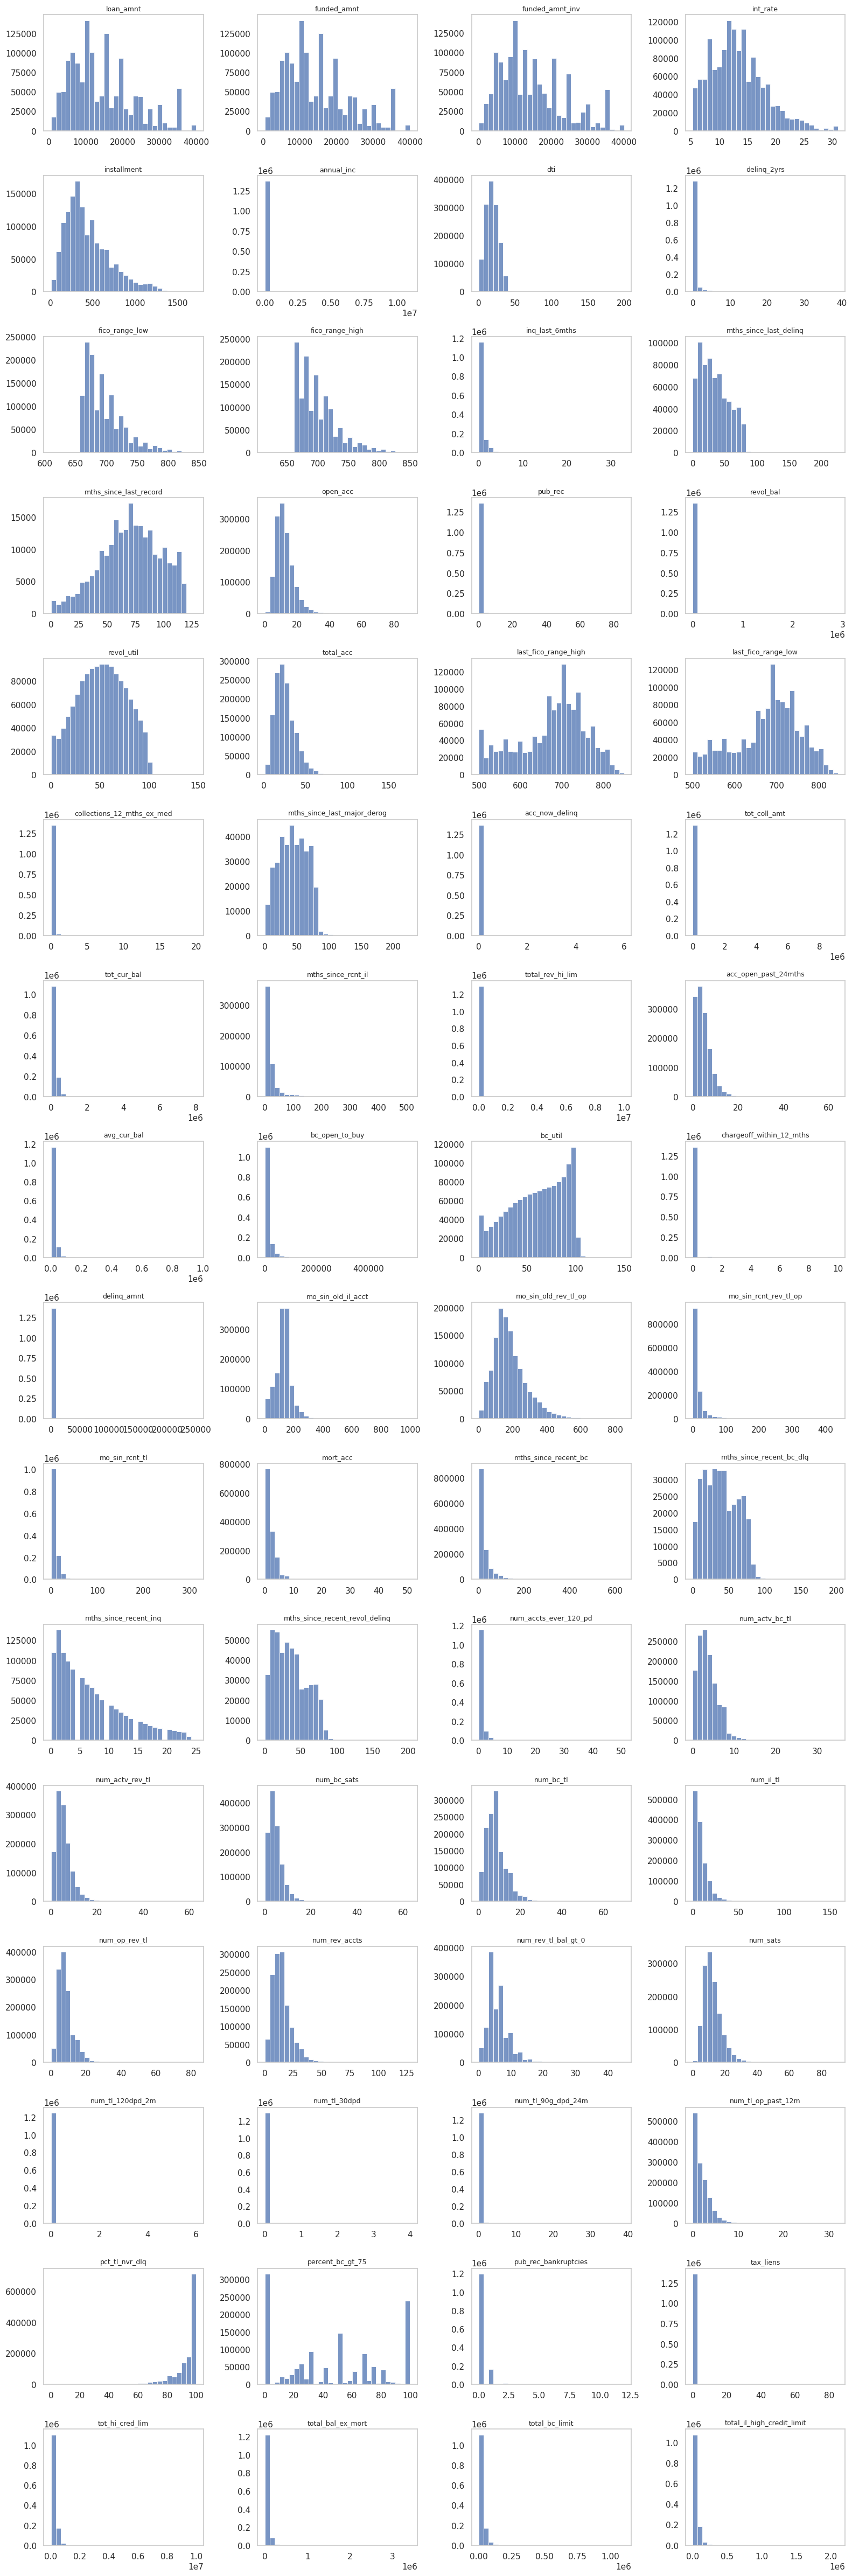

In [62]:
# Lista de variables numéricas que quieres graficar
cols = numerical_cols  # asegúrate que esta lista ya existe
n_cols = 4              # 4 gráficos por fila
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    sns.histplot(df[col], kde=False, bins=30, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Si sobran ejes (porque no es múltiplo de 4), apágalos
for j in range(len(cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Conclusión: Hay muchos datos que tienen una distribución sesgada, si aplicaramos regresiones lineales, usariamos algún metodo para tratarlos, pero como vamos a usar modelos de arboles, a estos modelos no les suele afectar mucho los datos atipicos

## Análisis Bivariado

### Numéricas vs Target

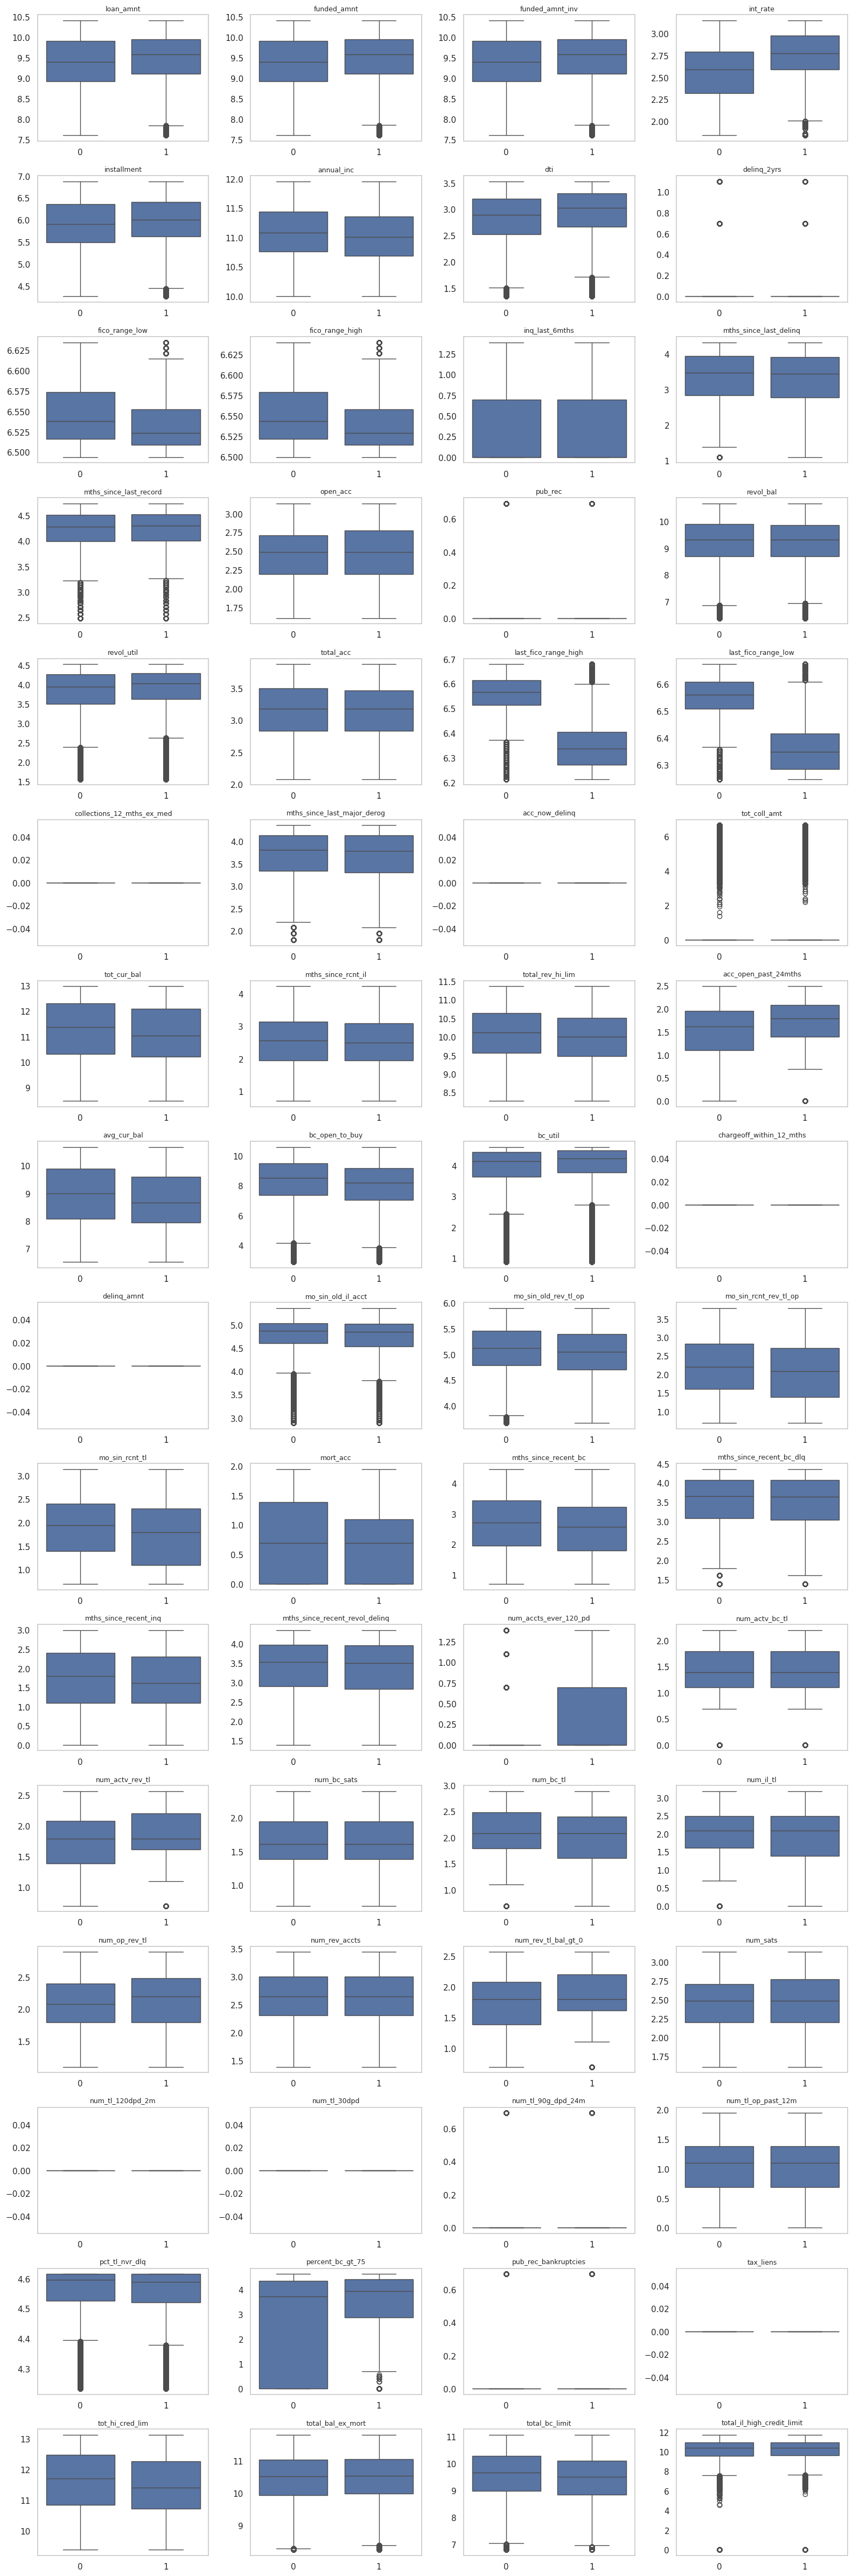

In [68]:
def plot_box_grid(df, cols, target_col, lower_q=0.01, upper_q=0.99, sample_n=None):
    # Opcional: muestreo para aligerar (útil si tienes > 500k filas)
    if sample_n is not None and len(df) > sample_n:
        df_plot = df.sample(sample_n, random_state=42).copy()
    else:
        df_plot = df.copy()

    # Clipping por columna (para que el boxplot no se deforme por extremos)
    for col in cols:
        low = df_plot[col].quantile(lower_q)
        high = df_plot[col].quantile(upper_q)
        df_plot[col] = df_plot[col].clip(lower=low, upper=high)

    n_cols = 4  # 4 gráficos por fila
    n_rows = math.ceil(len(cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.boxplot(x=df_plot[target_col], y=np.log1p(df_plot[col]), ax=ax)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(False)

    # Apagar ejes vacíos si no es múltiplo de 4
    for j in range(len(cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


plot_box_grid(
    df=df, 
    cols=numerical_cols, 
    target_col=TARGET,    # o "loan_status" si es string
    lower_q=0.02, 
    upper_q=0.95,
    sample_n=500000     # opcional, puedes quitarlo si quieres todo
)

Verificamos las variables pueden tener fuga de datos que todavía no hemos identificado o se nos ha pasado en el paso anterior:

Por ver la gráfica, hay 2 variables que marcan una gran diferencia en cuanto al target y al analizar su significado, nos damos cuenta que sí se debe a que hay fuga de datos, puesto que esto se obtiene despues de saber si el usuario ha pagado o no ha pagado. 

- 'last_fico_range_high',    # Futuro: FICO actualizado (no el de la solicitud)
- 'last_fico_range_low',     # Futuro: FICO actualizado (no el de la solicitud)

In [107]:
eliminar_vars.append("last_fico_range_high")
eliminar_vars.append("last_fico_range_low")

#### Variables numéricas que no se pueden visualizar correctamente con BoxPlot, puesto que tienen pocos números.

In [73]:
var_other_visualizacion = [
    'delinq_2yrs',
    'pub_rec',
    'acc_now_delinq',
    'collections_12_mths_ex_med',
    'chargeoff_within_12_mths',
    'delinq_amnt',
    'num_accts_ever_120_pd',
    'num_tl_30dpd',
    'num_tl_120dpd_2m',
    'num_tl_90g_dpd_24m',
    'tax_liens',
    'pub_rec_bankruptcies'
]

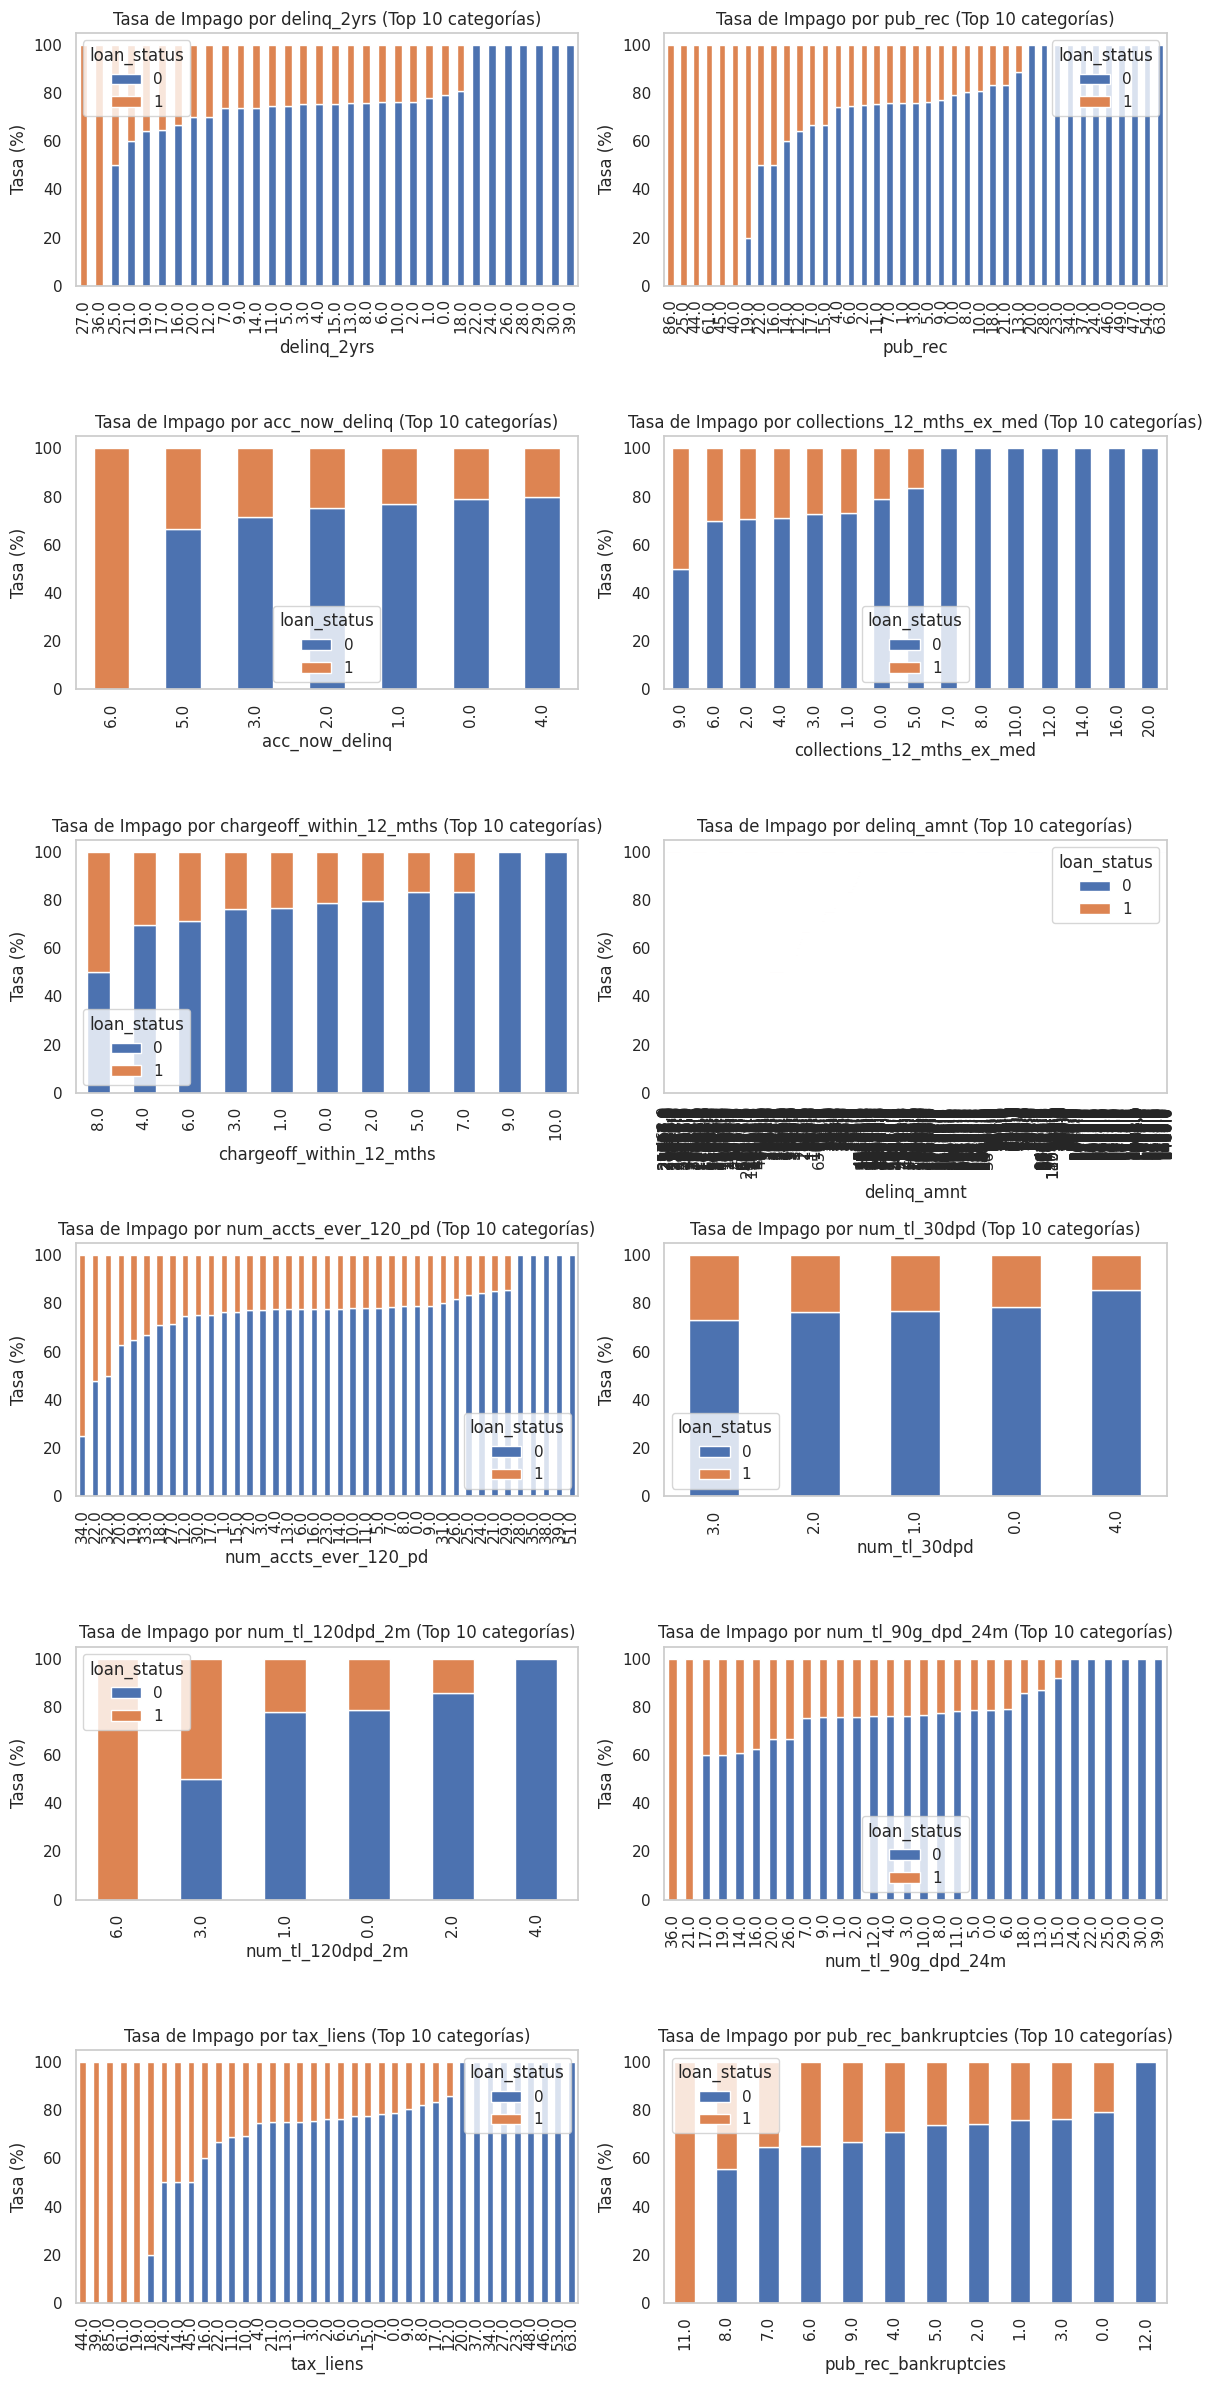

In [ ]:
cols = var_other_visualizacion
n_cols = 2  # gráficos por fila
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    # Crosstab normalizado por fila
    crosstab = pd.crosstab(df[col],df[TARGET],normalize='index') * 100

    # Ordenar por la clase positiva (default = 1)
    crosstab_sorted = crosstab.sort_values(by=1, ascending=False)
    # Plot
    crosstab_sorted.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        title=f'Tasa de Impago por {col} '
    )

    ax.set_ylabel('Tasa (%)')
    ax.grid(False)

# Apagar axes sobrantes si no es múltiplo exacto
for j in range(len(cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print(f"Análisis de la variable: {'delinq_amnt'}")
print("singifica: ", dictionary['delinq_amnt'])
print(df.groupby("delinq_amnt")[TARGET].mean())

Análisis de la variable: delinq_amnt
singifica:  Monto total que el cliente debe actualmente por pagos atrasados.
delinq_amnt
0.000        0.212
1.000        0.333
2.000        0.000
3.000        0.429
4.000        0.222
              ... 
110626.000   0.000
112524.000   1.000
130778.000   0.000
185408.000   0.000
249925.000   1.000
Name: loan_status, Length: 2030, dtype: float64


Conclusión: No detectamos algún tipo de fuga de datos, pero si variables que pueden ser muy utiles al analisis.
Por ejemplo:

- delinq_2yrs
- pub_rec
- acc_now_delinq
- num_tl_120dpd_2m
- num_lt_90g_dpd_24m
- tax_liens
- pub_rec

### Categoricas vs Target

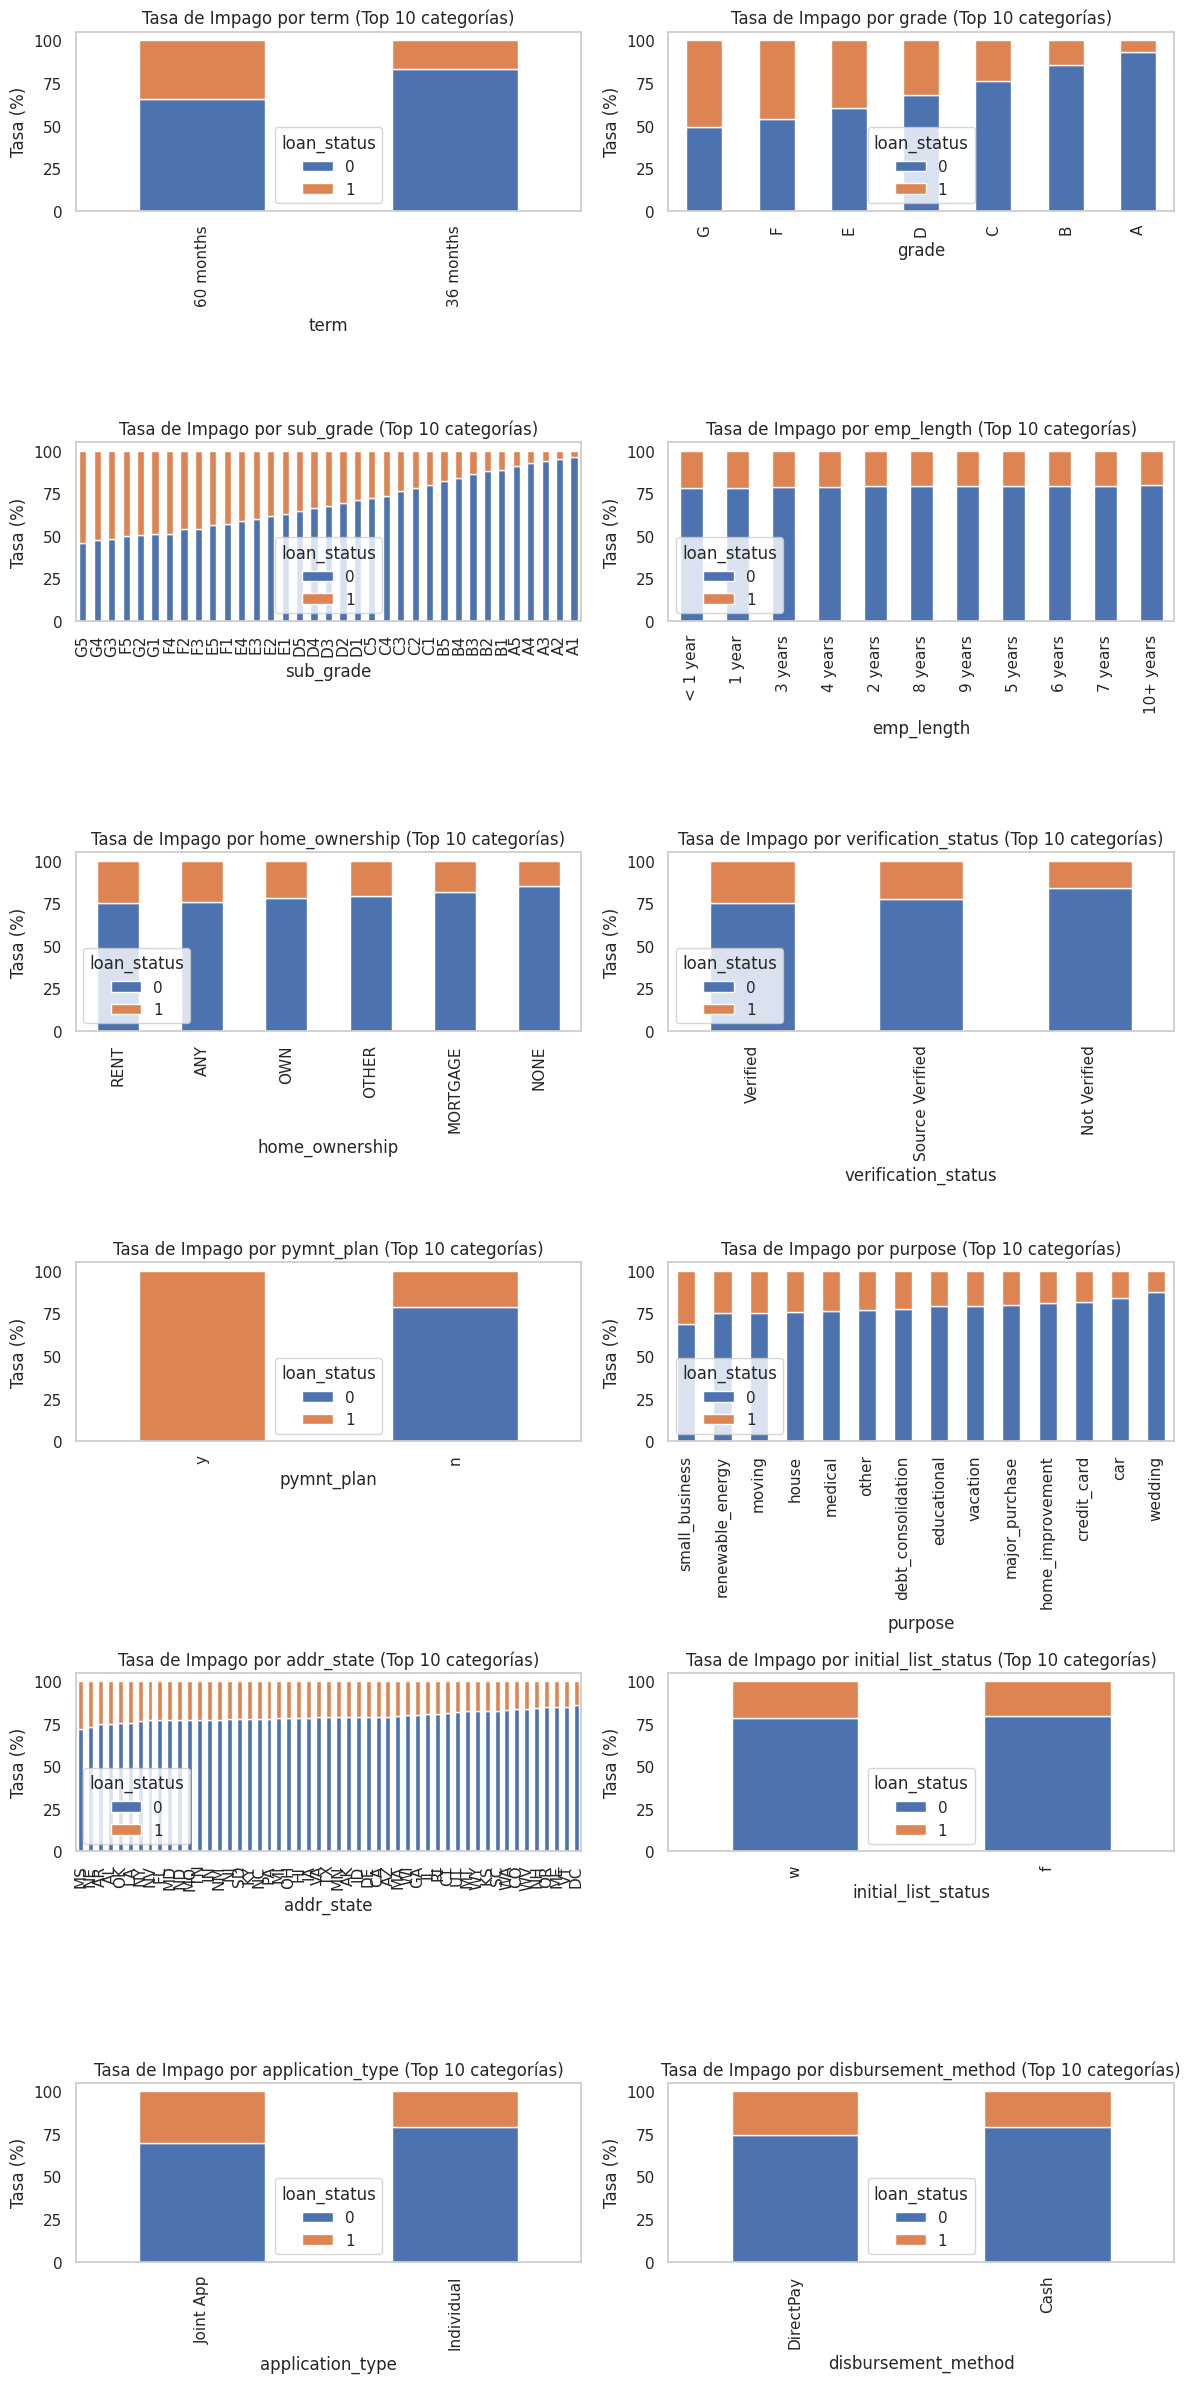

In [ ]:
cols = categorical_cols
n_cols = 2  # gráficos por fila
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    # Crosstab normalizado por fila
    crosstab = pd.crosstab(df[col],df[TARGET],normalize='index') * 100

    # Ordenar por la clase positiva (default = 1)
    crosstab_sorted = crosstab.sort_values(by=1, ascending=False)
    # Plot
    crosstab_sorted.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        title=f'Tasa de Impago por {col}'
    )

    ax.set_ylabel('Tasa (%)')
    ax.grid(False)

# Apagar axes sobrantes si no es múltiplo exacto
for j in range(len(cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Conclusión: La variable pymnt_plan es muy perfecta, y analizando lo que significa, concluimos que si es fuga de datos. Debemos eliminarla. Y se debe a que se crea solo si hay problemas con el pago.

In [108]:
eliminar_vars.append("pymnt_plan")

Conclusion de categóricas a eliminar por dimensionalidad y por no aportar mucho valor.

La variable "addr_state" aportaría muchas variables, y no se visualiza una gran diferenciacion en cuanto al target. Por ello la eliminaré.

In [122]:
eliminar_vars.append("addr_state")

Asimismo, tambien voy a eliminar la variable "grade" porque es muy similar a "sub_grade", y es una variable categorica ordinal que no aumentará la dimensionalidad.

In [123]:
eliminar_vars.append("grade")

In [125]:
print("Variables a eliminar por fuga de datos:" , eliminar_vars)

Variables a eliminar por fuga de datos: ['pymnt_plan', 'last_fico_range_high', 'last_fico_range_low', 'last_credit_pull_d', 'issue_d', 'addr_state', 'grade', 'addr_state', 'grade']


In [126]:
# Lista de variables de fuga de datos adicionales a eliminar
eliminar_vars = [
    'pymnt_plan',              # Soplón: Se crea solo si hay problemas
    'last_fico_range_high',    # Futuro: FICO actualizado (no el de la solicitud)
    'last_fico_range_low',     # Futuro: FICO actualizado (no el de la solicitud)
    'last_credit_pull_d',      # Futuro: Fecha de la última revisión (se actualiza)
    'issue_d',                 # Futuro: Ocurre DESPUÉS de la decisión de aprobar
    'addr_state',              # Variable eliminada por dimensionalidad y poco valor predictivo
    'grade'                    # Variable eliminada por redundancia con sub_grade
]

In [127]:
df.drop(columns=eliminar_vars, inplace=True)

In [128]:
df.shape

(1369566, 73)

## Análisis Multivariado

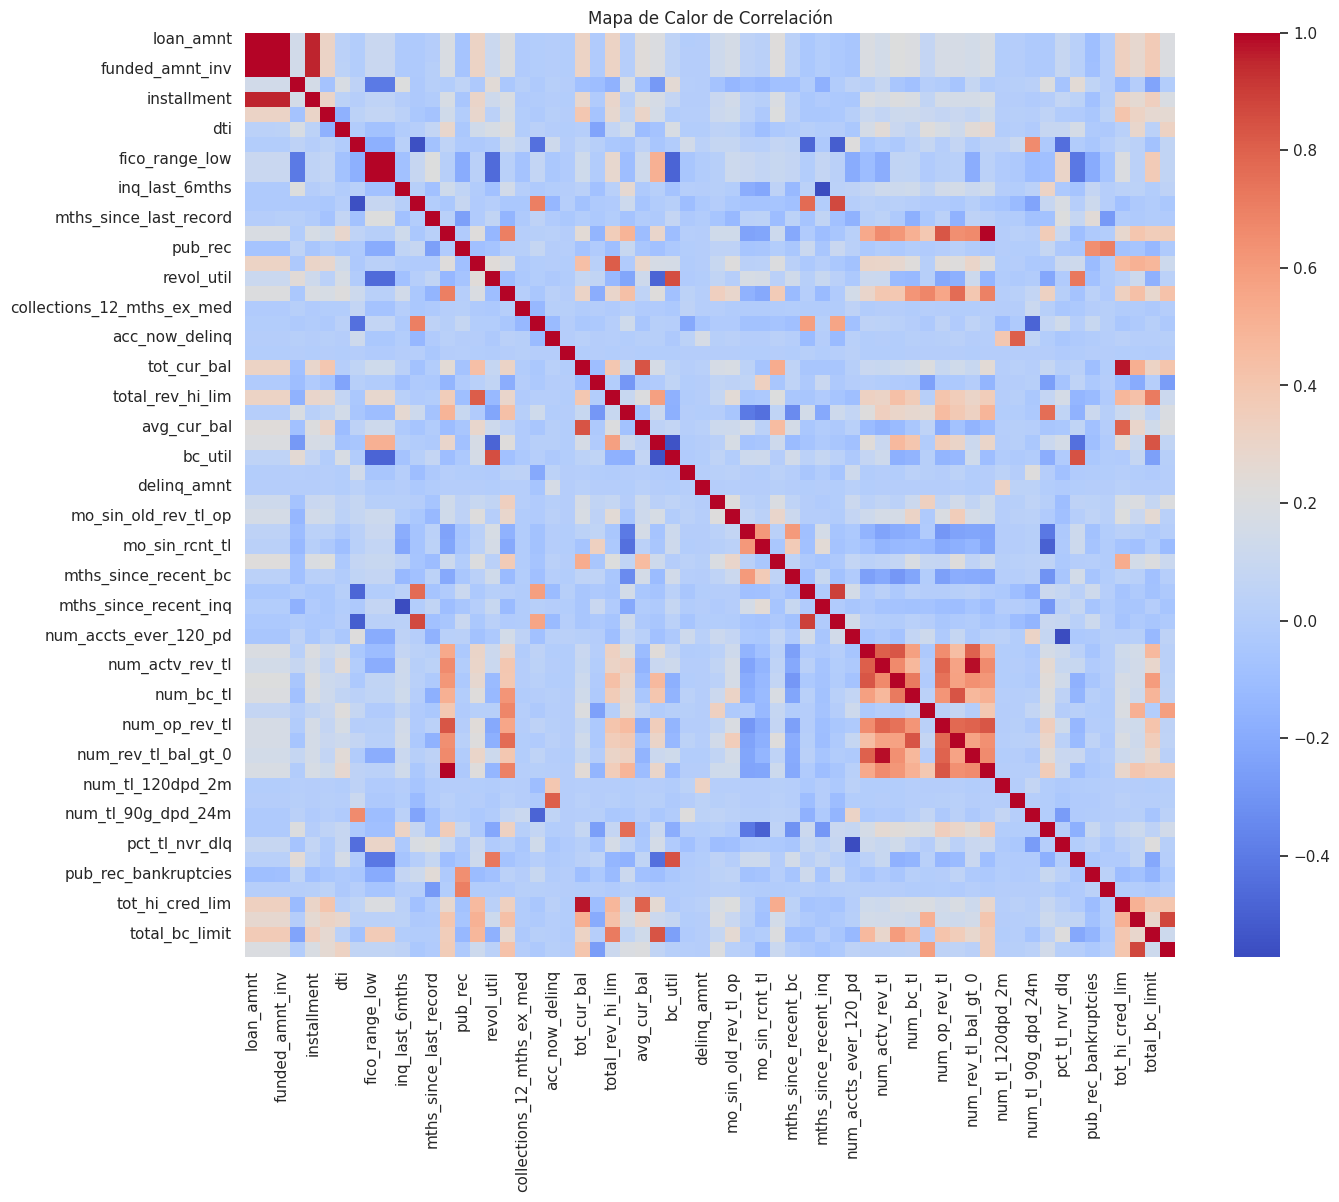

In [129]:
# Calcula la matriz de correlación

numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)
    
corr_matrix = df[numerical_cols].corr()

# Grafica el heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.1f')
plt.title('Mapa de Calor de Correlación')
plt.show()

In [131]:
print("--- 1. Buscando Pares de Variables Redundantes ---")

# 1. Calcula la matriz de correlación (solo para columnas numéricas)
corr_matrix = df[numerical_cols].corr().abs()

# 2. Selecciona el "triángulo superior" de la matriz (para evitar duplicados)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. "Desapila" (stack) la matriz para convertirla en una lista de pares
stacked_corr = upper_triangle.stack()

# 4. Define tu umbral y filtra la lista
umbral_correlacion = 0.90 # Empecemos con 90%
highly_correlated_pairs = stacked_corr[stacked_corr > umbral_correlacion]

print(f"Pares de variables con correlación > {umbral_correlacion}:")
print(highly_correlated_pairs)

# 5. Obtén una lista de variables a eliminar (una de cada par)
#    Esto toma el segundo elemento de cada par para eliminarlo
columnas_a_eliminar = highly_correlated_pairs.index.get_level_values(1).unique().tolist()

print(f"\nLista de columnas sugeridas para eliminar: {columnas_a_eliminar}")

--- 1. Buscando Pares de Variables Redundantes ---
Pares de variables con correlación > 0.9:
loan_amnt        funded_amnt           1.000
                 funded_amnt_inv       0.998
                 installment           0.953
funded_amnt      funded_amnt_inv       0.999
                 installment           0.954
funded_amnt_inv  installment           0.952
fico_range_low   fico_range_high       1.000
open_acc         num_sats              0.999
tot_cur_bal      tot_hi_cred_lim       0.973
num_actv_rev_tl  num_rev_tl_bal_gt_0   0.982
dtype: float64

Lista de columnas sugeridas para eliminar: ['funded_amnt', 'funded_amnt_inv', 'installment', 'fico_range_high', 'num_sats', 'tot_hi_cred_lim', 'num_rev_tl_bal_gt_0']


Para decidir cuales sacar, primero visualizamos quienes tienen mas datos faltantes

In [133]:
comparacion = ["loan_amnt", "funded_amnt", "funded_amnt_inv", "installment", 
               "fico_range_low", "fico_range_high", 
               "open_acc", "num_sats",
               "tot_cur_bal", "tot_hi_cred_lim",
               "num_actv_rev_tl", "num_rev_tl_bal_gt_0"]

for col in comparacion:
    print(f"Numero de columnas vacias: {col}")
    print(df[col].isnull().sum())

Numero de columnas vacias: loan_amnt
0
Numero de columnas vacias: funded_amnt
0
Numero de columnas vacias: funded_amnt_inv
0
Numero de columnas vacias: installment
0
Numero de columnas vacias: fico_range_low
0
Numero de columnas vacias: fico_range_high
0
Numero de columnas vacias: open_acc
29
Numero de columnas vacias: num_sats
58590
Numero de columnas vacias: tot_cur_bal
70276
Numero de columnas vacias: tot_hi_cred_lim
70276
Numero de columnas vacias: num_actv_rev_tl
70276
Numero de columnas vacias: num_rev_tl_bal_gt_0
70276


Conclusión:
- De la comparación de "open_acc", "num_sats". Se decide que la variable que se queda es ""open_acc".
- Todas las demás comparaciones tienen el mismo de valores faltantes

-------------------------------

Basándonos en estos pares, tomamos las siguientes decisiones:

1. Grupo `loan_amnt` (Monto del Préstamo)
* **Variables Correlacionadas:** `loan_amnt`, `funded_amnt`, `funded_amnt_inv`, `installment`.
* **Análisis:**
    * `loan_amnt` es la cantidad que el cliente solicitó (la "causa").
    * `funded_amnt` y `funded_amnt_inv` son la cantidad que el banco/inversores financiaron, lo cual es casi idéntico a lo solicitado.
    * `installment` (pago mensual) es un "efecto" que se *calcula* a partir de `loan_amnt`, `int_rate` y `term`.
* **Decisión:** **Mantenemos `loan_amnt`** (la característica causa raíz) y **eliminamos `funded_amnt`, `funded_amnt_inv` e `installment`** para evitar redundancia.

2. Grupo `fico_range` (Puntaje FICO)
* **Variables Correlacionadas:** `fico_range_low`, `fico_range_high`.
* **Análisis:** Ambas columnas describen la misma métrica (el puntaje FICO del cliente, entregado como un rango). Tienen una correlación de 1.0, lo que significa que son clones.
* **Decisión:** **Mantenemos `fico_range_low`** y **eliminamos `fico_range_high`**.

3. Grupo `tot_cur_bal` (Saldo Total)
* **Variables Correlacionadas:** `tot_cur_bal`, `tot_hi_cred_lim`.
* **Análisis:** `tot_cur_bal` (cuánto debes en total) y `tot_hi_cred_lim` (cuál es tu límite de crédito total). Aunque están altamente correlacionadas (la gente con límites altos tiende a deber más), miden dos conceptos de negocio fundamentalmente diferentes: `deuda` vs. `capacidad de endeudamiento`.
* **Decisión:** **MANTENEMOS AMBAS.** De hecho, en la ingeniería de características (notebook 03), usaremos estas dos para crear una nueva variable: `utilizacion_total = tot_cur_bal / tot_hi_cred_lim`.

4. Grupo `num_actv_rev_tl` (Cuentas Revolventes Activas)
* **Variables Correlacionadas:** `num_actv_rev_tl`, `num_rev_tl_bal_gt_0`.
* **Análisis:** `num_actv_rev_tl` (número de cuentas revolventes activas) y `num_rev_tl_bal_gt_0` (número de cuentas revolventes con un saldo > 0) miden lo mismo. Una cuenta "activa" es aquella que tiene un saldo.
* **Decisión:** **Mantenemos `num_actv_rev_tl`** y **eliminamos `num_rev_tl_bal_gt_0`**.

In [135]:
columnas_a_eliminar_redundancia = [
    'funded_amnt', 
    'funded_amnt_inv', 
    'installment', 
    'fico_range_high',
    'num_sats',
    'num_rev_tl_bal_gt_0'
]

df = df.drop(columns=columnas_a_eliminar_redundancia)

In [136]:
df.shape

(1369566, 67)

In [137]:
print("\n--- 2. Buscando Variables Constantes (Varianza Cero) ---")

# 1. Calcula el número de valores únicos para cada columna
conteo_unicos = df.nunique()

# 2. Encuentra las columnas que tienen un solo valor único
columnas_constantes = conteo_unicos[conteo_unicos == 1].index.tolist()

if columnas_constantes:
    print(f"Encontradas {len(columnas_constantes)} columnas constantes para eliminar:")
    print(columnas_constantes)
    
    # 3. (Opcional) Elimínalas
    # df_final = df_sin_multicolinealidad.drop(columns=columnas_constantes)
else:
    print("No se encontraron columnas constantes.")


--- 2. Buscando Variables Constantes (Varianza Cero) ---
No se encontraron columnas constantes.


## PASO FINAL 
- GUARDAMOS LOS CAMBIOS DEL DATAFRAME EN UNO NUEVO

In [138]:
# Guardas el nuevo DataFrame intermedio
output_path = "../data/interim/eda_features_selected.parquet"
df.to_parquet(output_path, index=False)

print(f"DataFrame filtrado por EDA guardado en {output_path}")

DataFrame filtrado por EDA guardado en ../data/interim/eda_features_selected.parquet
